In [1]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split

# 记录开始时间
start_time = time.time()

# 定义超参数
batch_size = 64
learning_rate = 0.001
num_epochs = 100

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'
image_datasets = datasets.ImageFolder(data_dir, data_transforms)

# 划分训练集和测试集
train_data, test_data = train_test_split(image_datasets, test_size=0.3, random_state=42)

dataloaders = {'train':torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4),
               'val':torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4)}
dataset_sizes = {'train': len(train_data),'val': len(test_data)}

In [2]:
model = models.densenet121(pretrained=True)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 4)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

for param in model.features.parameters():
    param.requires_grad = False

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), 
                      lr=learning_rate, momentum=0.9)

# 训练模型
result = {
          "acu_train": [],
          "acu_test": [],
          "loss_train":[],
          "recall": []
          }
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        
        if phase=='train':
            result["acu_train"].append('{:.4f}'.format(epoch_acc))
            result["loss_train"].append('{:.4f}'.format(epoch_loss))
        elif phase=='val':
            result["acu_test"].append('{:.4f}'.format(epoch_acc))
            recall = recall_score(labels.data.detach().cpu().numpy(), preds.detach().cpu().numpy(), average="macro")
            result["recall"].append(recall)

        print('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}'.format(epoch, phase, epoch_loss, epoch_acc))
        with open('C:/Users/WHS/Desktop/Dual-ResNet18-SVM/result/result_file_DenseNet121.txt', "a") as file:
            file.write('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}\n'.format(epoch, phase, epoch_loss, epoch_acc))

epoch: 0, train Loss: 1.4944 Acc: 0.2287
epoch: 0, val Loss: 1.4401 Acc: 0.3018
epoch: 1, train Loss: 1.2395 Acc: 0.4612
epoch: 1, val Loss: 1.2575 Acc: 0.3694
epoch: 2, train Loss: 1.0262 Acc: 0.6531
epoch: 2, val Loss: 1.1682 Acc: 0.5000
epoch: 3, train Loss: 0.8605 Acc: 0.7655
epoch: 3, val Loss: 1.0311 Acc: 0.5991
epoch: 4, train Loss: 0.7464 Acc: 0.7868
epoch: 4, val Loss: 0.8914 Acc: 0.6577
epoch: 5, train Loss: 0.7041 Acc: 0.7655
epoch: 5, val Loss: 0.8248 Acc: 0.7162
epoch: 6, train Loss: 0.6551 Acc: 0.8004
epoch: 6, val Loss: 0.7129 Acc: 0.7973
epoch: 7, train Loss: 0.5922 Acc: 0.8081
epoch: 7, val Loss: 0.6574 Acc: 0.7838
epoch: 8, train Loss: 0.5646 Acc: 0.8566
epoch: 8, val Loss: 0.6098 Acc: 0.8063
epoch: 9, train Loss: 0.5361 Acc: 0.8411
epoch: 9, val Loss: 0.5847 Acc: 0.7613
epoch: 10, train Loss: 0.5040 Acc: 0.8702
epoch: 10, val Loss: 0.5568 Acc: 0.8153
epoch: 11, train Loss: 0.4532 Acc: 0.8876
epoch: 11, val Loss: 0.5107 Acc: 0.8243
epoch: 12, train Loss: 0.4314 Acc: 0

In [3]:
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time)

456.64438223838806


In [4]:
torch.save(model.state_dict(), 'DenseNet121.pth')

In [1]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split
start_time = time.time()
data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images3'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms) for x in ['train', 'val']}
test_loader = torch.utils.data.DataLoader(image_datasets['val'], batch_size=64, shuffle=True, num_workers=4)

model = models.densenet121()
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 4)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

for param in model.features.parameters():
    param.requires_grad = False
# 加载之前保存的模型参数
model.load_state_dict(torch.load('DenseNet121.pth'))


for inputs, labels in test_loader:    
    inputs = inputs.to(device)
    labels = labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    print(labels,preds)
    break
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time/len(labels))

tensor([2, 3, 1, 0, 0, 1, 1, 3, 1, 2, 3, 1, 1, 2, 3, 2, 3, 0, 3, 0, 0, 1, 3, 0,
        1, 1, 1, 0, 0, 2, 2, 2, 1, 3, 3, 1, 3, 1, 3, 2, 2, 2, 0, 0, 3, 0, 0, 3,
        2, 0, 1, 0, 0, 0, 3, 2, 2, 1, 3, 3, 2, 1, 3, 1], device='cuda:0') tensor([2, 3, 1, 0, 0, 1, 1, 3, 1, 2, 3, 1, 2, 2, 3, 2, 0, 0, 3, 0, 0, 1, 3, 0,
        1, 1, 1, 0, 1, 2, 2, 2, 1, 3, 3, 1, 3, 3, 0, 2, 2, 2, 0, 0, 3, 3, 3, 3,
        2, 0, 1, 0, 0, 0, 0, 2, 2, 1, 3, 3, 2, 1, 3, 1], device='cuda:0')
0.07462622225284576


In [2]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


"""Use this method directly - """
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    matplotlib.rcParams['font.size'] = 18
    matplotlib.rcParams['font.family'] = 'Times New Roman'
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    fig.subplots_adjust(left=0.2, bottom=0.2)
    fig.savefig('DenseNet121_con.png', dpi=300)
    plt.tight_layout()

In [3]:
labels = labels.cpu()
preds = preds.cpu()
cnf_matrix = confusion_matrix(labels.data, preds)
print(cnf_matrix)

[[13  1  0  2]
 [ 0 15  1  1]
 [ 0  0 14  0]
 [ 3  0  0 14]]


Normalized confusion matrix
[[0.8125     0.0625     0.         0.125     ]
 [0.         0.88235294 0.05882353 0.05882353]
 [0.         0.         1.         0.        ]
 [0.17647059 0.         0.         0.82352941]]


<ipython-input-2-ee55a21cbc4e>:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


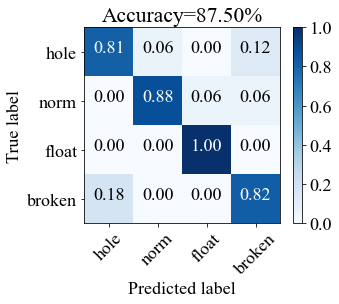

In [4]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(labels.data, preds)
plt.figure()
plot_confusion_matrix(cnf_matrix, ['hole','norm','float','broken'],normalize=True,title='Accuracy={:.2f}%'.format(accuracy*100),cmap=plt.cm.Blues)